In [14]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [15]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
)

In [16]:
from collections import defaultdict

strategies = [PluralityStrategy(), BordaCountStrategy()]

C_values = [5, 10, 25, 50, 100]
V_values = [25, 50, 100, 200, 500]
N_CONFIGS = 20  # candidate configurations per (C, V)
N_VOTER_SAMPLES = 10  # voter draws per candidate configuration
MIN_RATIO = 4  # only keep (C, V) cells with at least this many voters per candidate

# nested_results[(C, V)] = list of groups; each group = list of ElectionResult
# sharing one candidate configuration but different voter draws
nested_results: dict[tuple, list[list[ElectionResult]]] = defaultdict(list)

n_total = 0
n_tied = 0

for C in C_values:
    for V in V_values:
        if (
            V / C < MIN_RATIO
        ):  # skip degenerate regime where plurality is structurally tied
            continue
        for _ in range(N_CONFIGS):
            candidates = [
                Candidate(id=id, position=random_2d_point()) for id in range(C)
            ]

            group: list[ElectionResult] = []
            for _ in range(N_VOTER_SAMPLES):
                voters = [Voter(position=random_2d_point()) for _ in range(V)]
                election = Election(candidates=candidates, voters=voters)
                result = election.compare_strategies(strategies=strategies)

                n_total += 1
                if any(t.is_tie() for t in result.tallies.values()):
                    n_tied += 1

                group.append(result)

            nested_results[(C, V)].append(group)

print(f"tied elections: {n_tied}/{n_total} ({n_tied / n_total:.1%})")

tied elections: 264/3000 (8.8%)


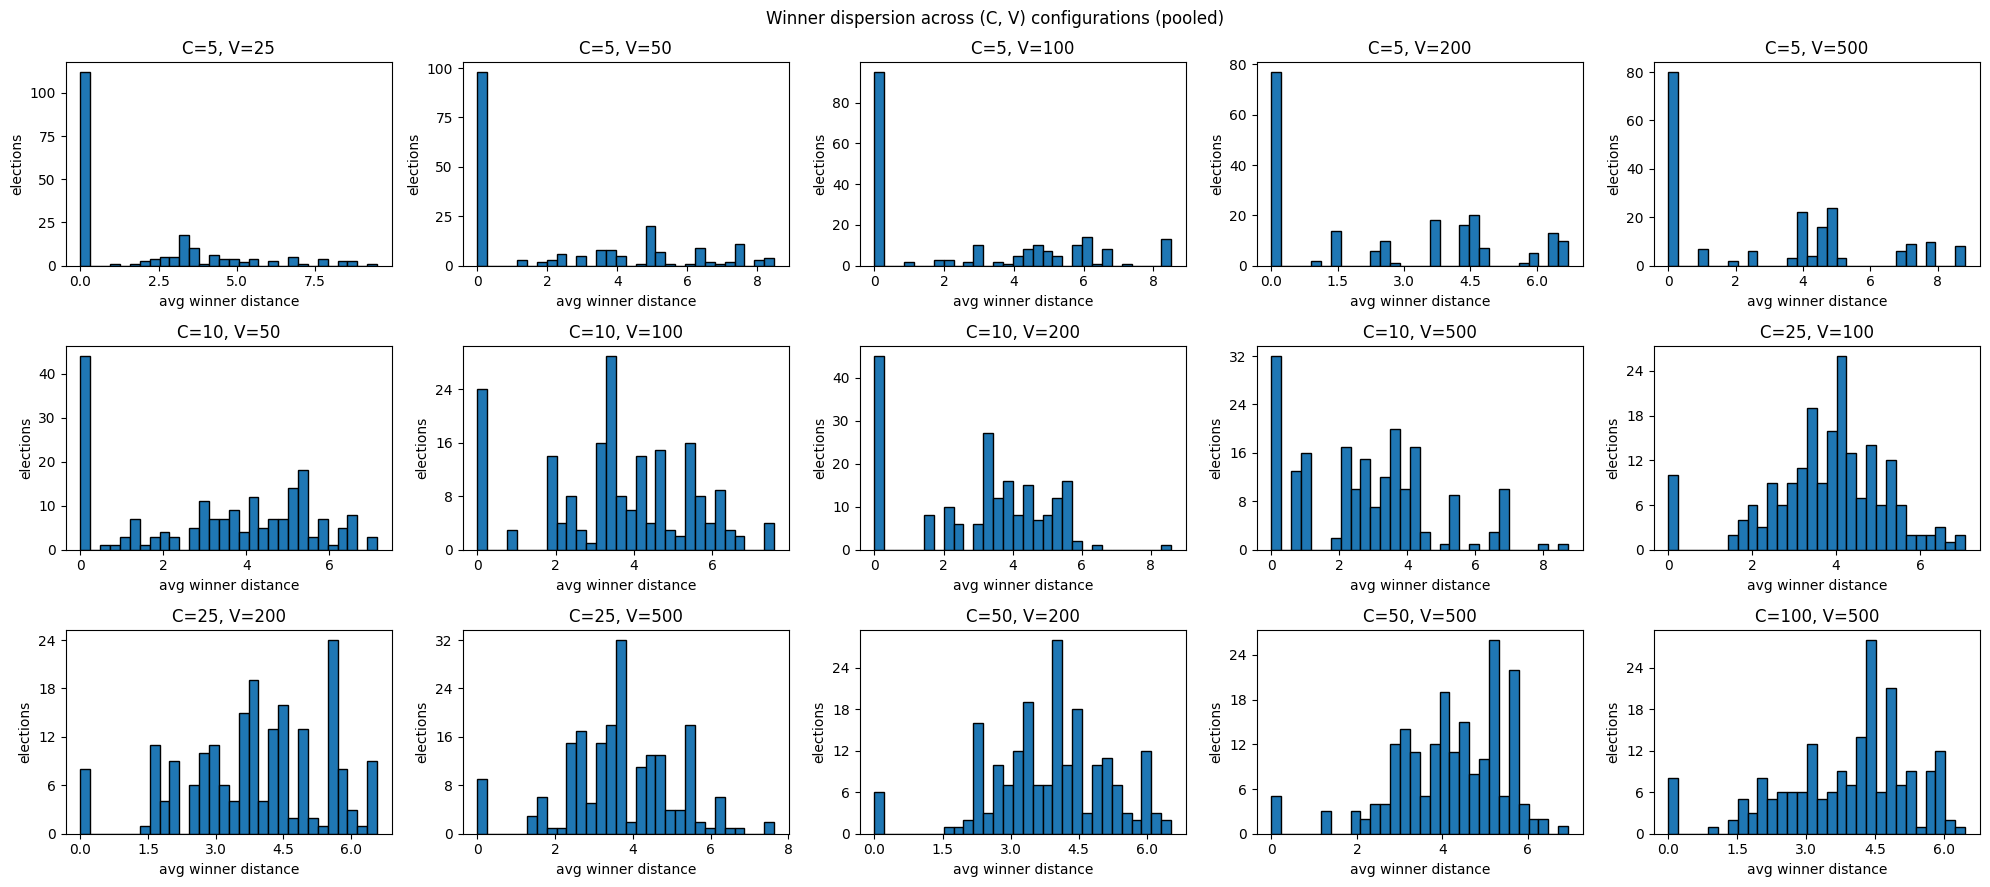

In [17]:
# Only the (C, V) cells that were actually generated (V/C >= MIN_RATIO), packed
# into a compact grid with no empty gaps. Set N_COLS = len(cells) for a single row.
cells = [(C, V) for C in C_values for V in V_values if nested_results[(C, V)]]

N_COLS = 5
n_rows = -(-len(cells) // N_COLS)  # ceil division

fig, axes = plt.subplots(
    n_rows, N_COLS, figsize=(4 * N_COLS, 3 * n_rows), squeeze=False
)
for ax in axes.flat:
    ax.axis("off")  # hide leftover slots; switch on only the ones we fill

for k, (C, V) in enumerate(cells):
    ax = axes[k // N_COLS][k % N_COLS]
    ax.axis("on")
    flat = [r for group in nested_results[(C, V)] for r in group]
    distances = ResultsAnalyzer(flat).winner_distance_series()

    plot_winner_distance_histogram(distances=distances, bins=30, ax=ax)
    ax.set_title(f"C={C}, V={V}")
    ax.set_xlabel("avg winner distance")
    ax.set_ylabel("elections")

fig.suptitle("Winner dispersion across (C, V) configurations (pooled)")
fig.tight_layout()
plt.show()

In [18]:
# Variance decomposition per (C, V):
# - between: std of per-config means (sensitivity to candidate placement)
# - within:  mean of per-config stds  (sensitivity to voter draw, candidates fixed)
print(f"{'C':>5} {'V':>5} {'mean':>8} {'between':>9} {'within':>8}")
for C in C_values:
    for V in V_values:
        groups = nested_results[(C, V)]
        if not groups:  # cell skipped (V/C below MIN_RATIO)
            continue
        per_config_means = [
            float(np.mean(ResultsAnalyzer(g).winner_distance_series())) for g in groups
        ]
        per_config_stds = [
            float(np.std(ResultsAnalyzer(g).winner_distance_series())) for g in groups
        ]
        print(
            f"{C:>5} {V:>5} "
            f"{np.mean(per_config_means):>8.3f} "
            f"{np.std(per_config_means):>9.3f} "
            f"{np.mean(per_config_stds):>8.3f}"
        )

    C     V     mean   between   within
    5    25    1.991     1.340    1.889
    5    50    2.540     1.710    2.073
    5   100    2.722     2.181    1.706
    5   200    2.562     1.855    1.113
    5   500    3.007     2.355    0.998
   10    50    3.288     1.249    1.703
   10   100    3.600     1.239    1.255
   10   200    3.055     0.895    1.437
   10   500    2.788     1.339    1.070
   25   100    3.773     0.626    1.173
   25   200    3.887     0.863    1.148
   25   500    3.687     0.971    0.857
   50   200    3.904     0.691    1.009
   50   500    4.181     0.751    0.956
  100   500    3.867     0.683    1.176
